In [1]:
import os
import pickle
import pathlib

import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import seaborn as sns
import pandas as pd
import pingouin as pg

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice


plt.rcParams['pdf.fonttype']=42
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/figS8_novel_activity_rate')
figdir.mkdir(exist_ok=True, parents=True)

In [3]:
# get average 

In [4]:
block_rate = stx.novel_activity_rate.BlockTransitionActivityRate(ts_key='F_dff')

4467331.1
4467331.2
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
4467332.1
4467332.2
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
4467333.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


mCherry6
mCherry7
mCherry8
mCherry9
4467975.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.2


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.3


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.4
4467975.5
Cre7
Cre9


In [5]:
block_rate.activity_rates['ctrl'][ctrl_mice[0]][0]['block_fam_act']
270
105

105

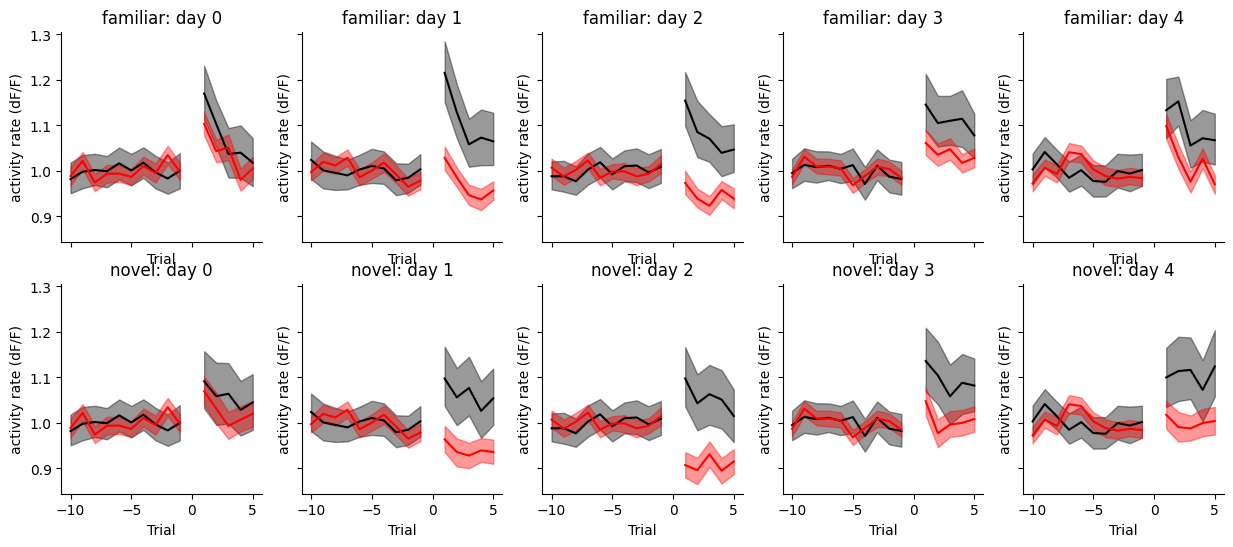

In [10]:
key = 'act'
n_perms = 1000
rng = np.random.default_rng()
max_trial = 5
fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)

for day in range(5):
    base = {'ctrl': np.zeros([n_perms,10])*np.nan, 'ko': np.zeros([n_perms,10])*np.nan}
    fam = {'ctrl': np.zeros([n_perms,max_trial])*np.nan, 'ko': np.zeros([n_perms,max_trial])*np.nan}
    nov = {'ctrl': np.zeros([n_perms,max_trial])*np.nan, 'ko': np.zeros([n_perms,max_trial])*np.nan}

    for cond, mice in zip(['ctrl','ko'], [ctrl_mice, ko_mice]):
        if cond == 'ko':
            n_cells = 270
        else:
            n_cells = 105
        
        for perm in range(n_perms):
            _base = np.nan*np.ones((len(mice), 10))
            _fam = np.nan*np.ones((len(mice), max_trial))
            _nov = np.nan*np.ones((len(mice), max_trial))

            for i, mouse in enumerate(mice):
                data = block_rate.activity_rates[cond][mouse][day]

                n_cells = np.minimum(n_cells, data[f'baseline_{key}'].shape[-1])

                
                cells = rng.permutation(data[f'baseline_{key}'].shape[-1])[:n_cells]

                __base = np.nanmean(np.nanmean(data[f'baseline_{key}'][:,:,cells],axis=1),axis=-1)
                __fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'][:,:,cells],axis=1),axis=-1)[:max_trial]
                __nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'][:,:,cells],axis=1), axis=-1)[:max_trial]
                # print(__base.shape)
                _base[i,:__base.shape[0]] = __base/__base.mean()
                _fam[i,:__fam.shape[0]] = __fam/__base.mean()
                _nov[i,:__nov.shape[0]] = __nov/__base.mean()

            base[cond][perm,:] = np.nanmean(_base, axis=0)
            fam[cond][perm,:] = np.nanmean(_fam, axis=0)
            nov[cond][perm,:] = np.nanmean(_nov, axis=0)

  
    for cond, color in zip(('ctrl','ko'), ('black', 'red')):
            x_base = np.arange(-10,0)
            mu, min, max = np.nanmedian(base[cond], axis=0), np.nanpercentile(base[cond], 5, axis=0), np.nanpercentile(base[cond], 95, axis=0)
            ax[0,day].plot(x_base, mu, color=color)
            ax[0,day].fill_between(x_base, min , max, alpha=.4, color=color)

            ax[1,day].plot(x_base, mu, color=color)
            ax[1,day].fill_between(x_base, min , max, alpha=.4, color=color)

            x_block = np.arange(1,max_trial+1)
            mu, min, max = np.nanmedian(fam[cond], axis=0), np.nanpercentile(fam[cond], 5, axis=0), np.nanpercentile(fam[cond], 95, axis=0)
            ax[0,day].plot(x_block, mu, color=color)
            ax[0,day].fill_between(x_block, min , max, alpha=.4, color=color)

            mu, min, max = np.nanmedian(nov[cond], axis=0), np.nanpercentile(nov[cond], 5, axis=0), np.nanpercentile(nov[cond], 95, axis=0)
            ax[1,day].plot(x_block, mu, color=color)
            ax[1,day].fill_between(x_block, min , max, alpha=.4, color=color)

            ax[0,day].set_title(f'familiar: day {day}')
            ax[1,day].set_title(f'novel: day {day}')

    for a in ax.flatten():
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)
        if key == 'act':
            a.set_ylabel('activity rate (dF/F)')
        else:
            a.set_ylabel(key)
        a.set_xlabel('Trial')
# fig.savefig(figdir / f"block_avg_downsample_95thpercentile_matchedCellCounts.pdf")

In [17]:
def plot_block_avg_downsample(block_rate, key='act', norm = 'population', max_trial=5):
    fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)
    rng = np.random.default_rng()

    for day in np.arange(5):
        base = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
        fam = {'ctrl': np.zeros([len(ctrl_mice),max_trial])*np.nan, 'ko': np.zeros([len(ko_mice),max_trial])*np.nan}
        nov = {'ctrl': np.zeros([len(ctrl_mice),max_trial])*np.nan, 'ko': np.zeros([len(ko_mice),max_trial])*np.nan}

        for cond, mice in zip(('ctrl','ko'), (ctrl_mice, ko_mice)):
            if cond == 'ko':
                n_cells = 270
            else:
                n_cells = 105


            for i, mouse in enumerate(mice):
                data = block_rate.activity_rates[cond][mouse][day]

                n_cells = np.minimum(n_cells, data[f'baseline_{key}'].shape[-1])
                cells = rng.permutation(data[f'baseline_{key}'].shape[-1])[:n_cells]

                _base = np.nanmean(np.nanmean(data[f'baseline_{key}'][:,:,cells],axis=1),axis=-1)
                _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'][:,:,cells],axis=1),axis=-1)[:max_trial]
                _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'][:,:,cells],axis=1), axis=-1)[:max_trial]
        
                base[cond][i,:_base.shape[0]] = _base/_base.mean()
                fam[cond][i,:_fam.shape[0]] = _fam/_base.mean()
                nov[cond][i,:_nov.shape[0]] = _nov/_base.mean()
                

        for cond, color in zip(('ctrl','ko'), ('black', 'red')):
            x_base = np.arange(-10,0)
            mu, sem = np.nanmean(base[cond], axis=0), sp.stats.sem(base[cond],axis=0, nan_policy='omit')
            ax[0,day].plot(x_base, mu, color=color)
            ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            ax[1,day].plot(x_base, mu, color=color)
            ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            x_block = np.arange(1,max_trial+1)
            mu, sem = np.nanmean(fam[cond], axis=0), sp.stats.sem(fam[cond],axis=0, nan_policy='omit')
            ax[0,day].plot(x_block, mu, color=color)
            ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
            ax[1,day].plot(x_block, mu, color=color)
            ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            ax[0,day].set_title(f'familiar: day {day}')
            ax[1,day].set_title(f'novel: day {day}')

    for a in ax.flatten():
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)
        if key == 'act':
            a.set_ylabel('activity rate (dF/F)')
        else:
            a.set_ylabel(key)
        a.set_xlabel('Trial')
    return fig, ax

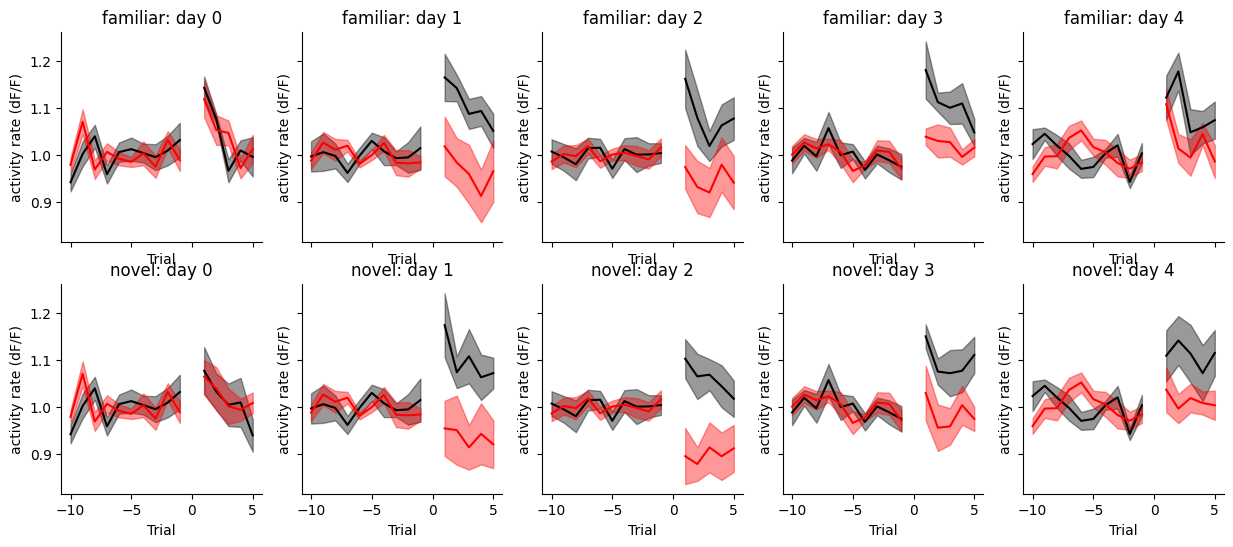

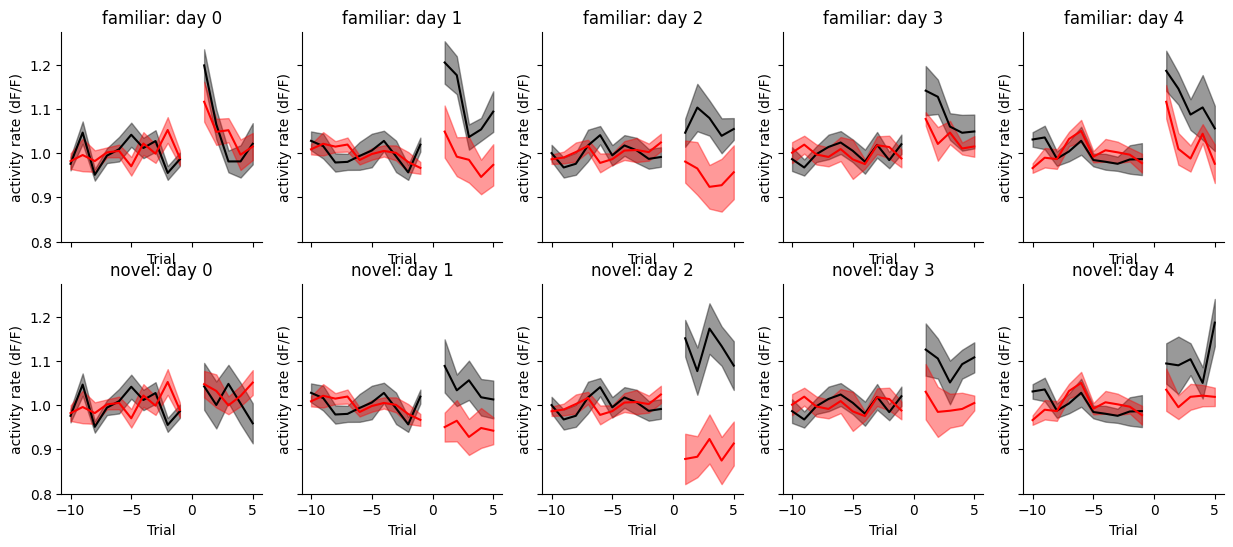

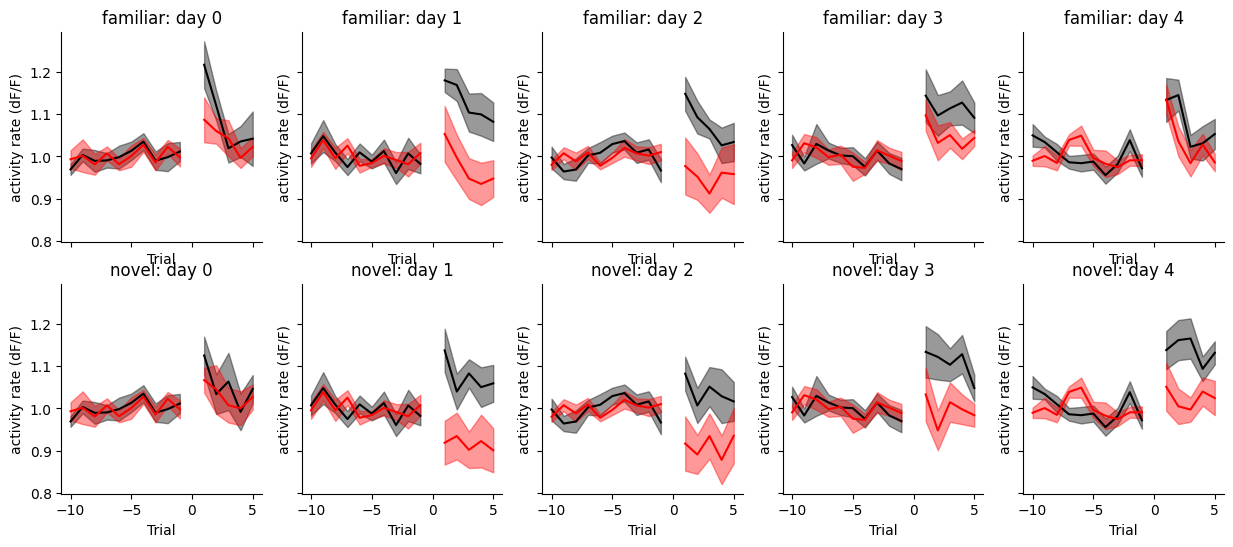

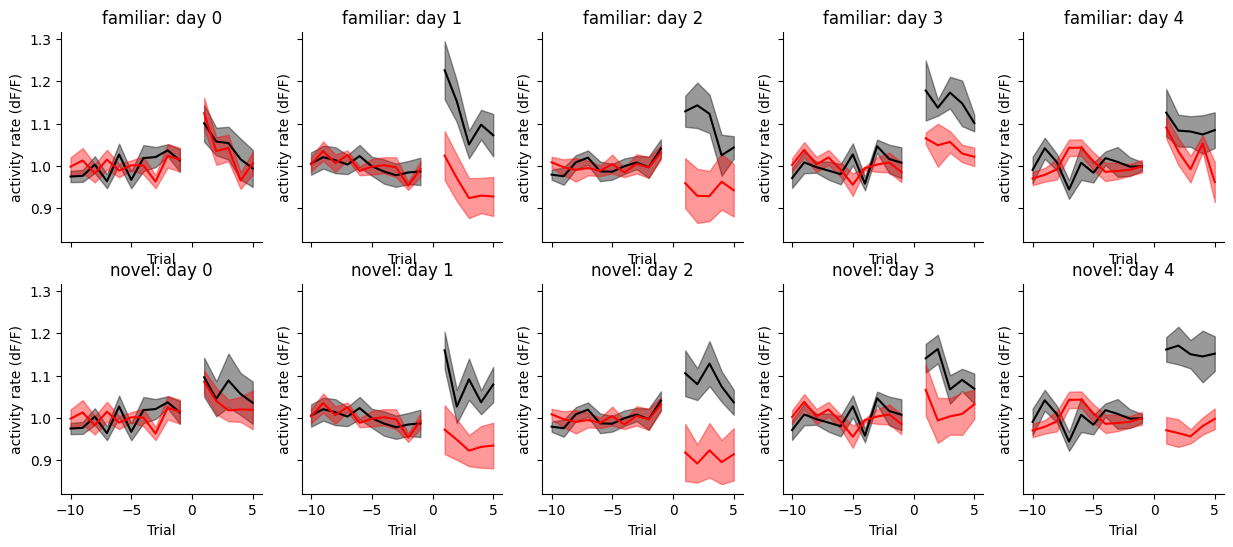

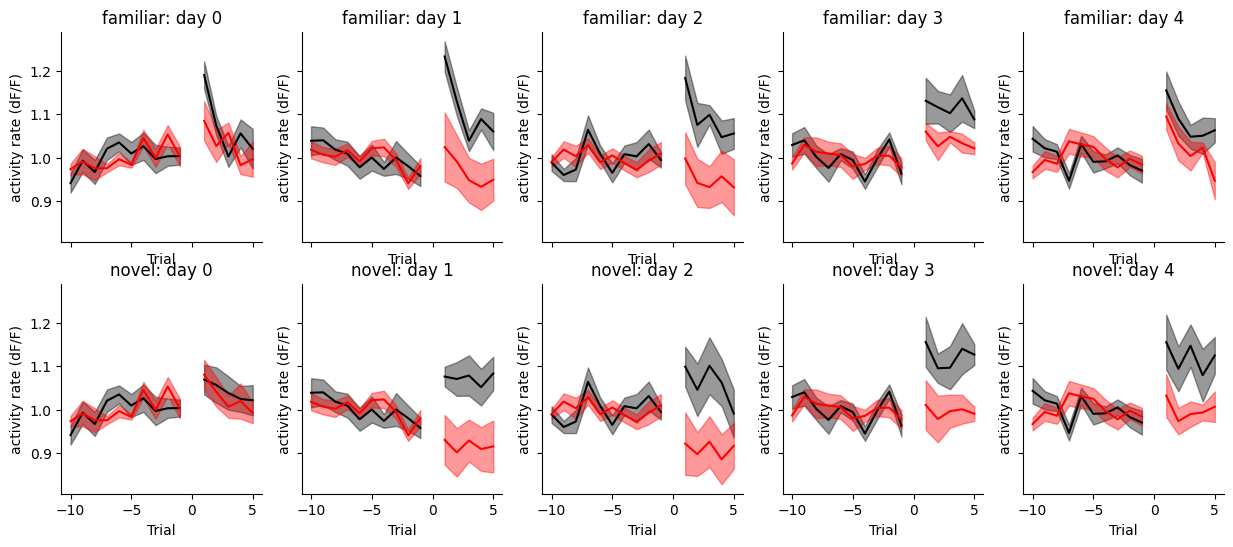

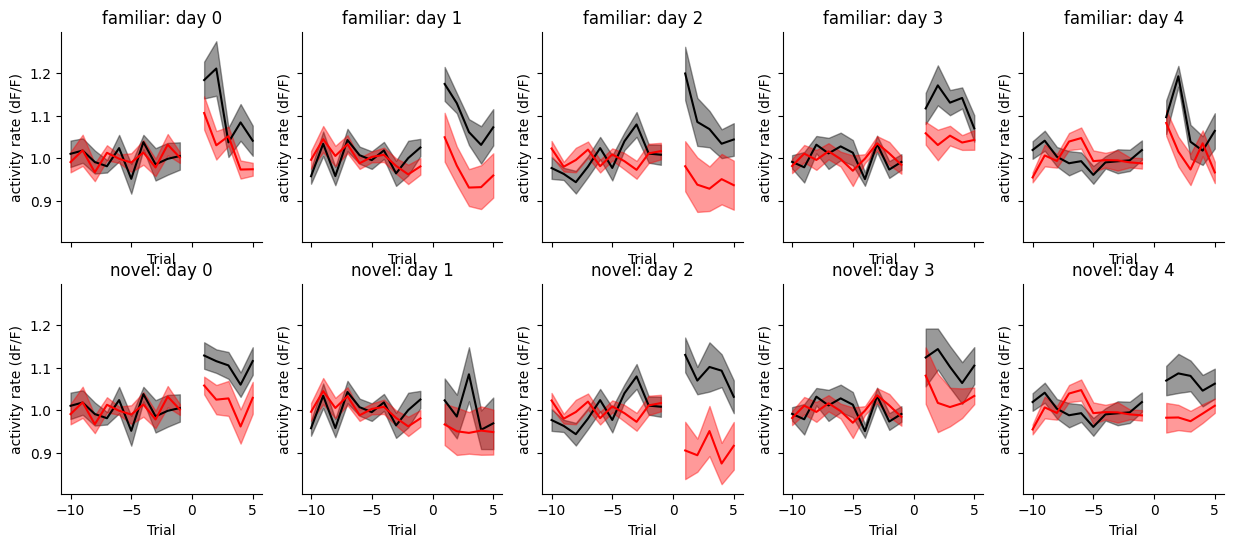

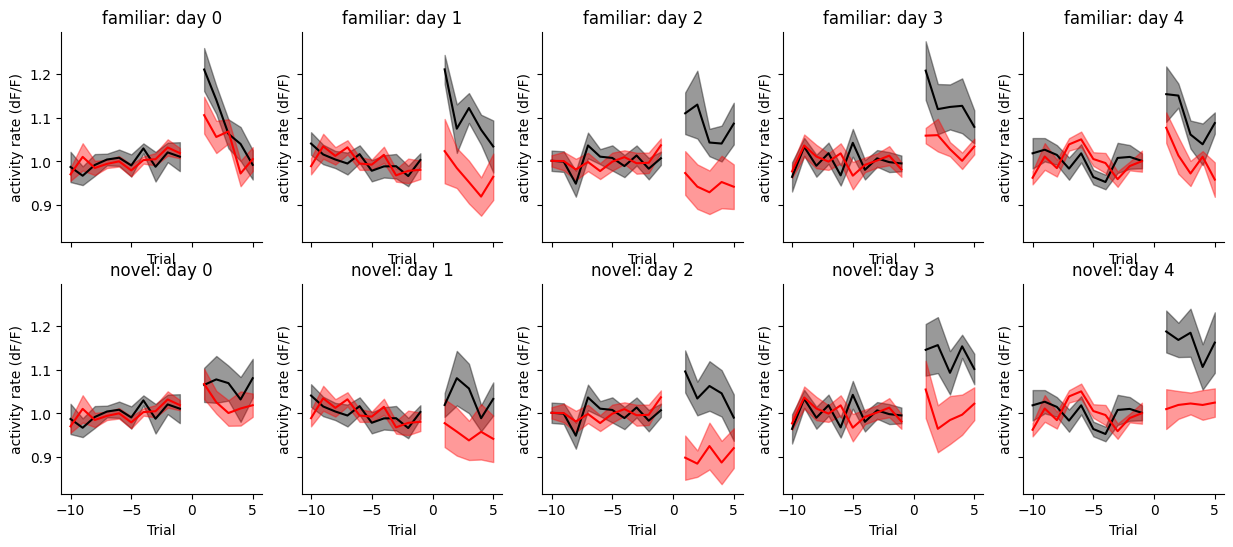

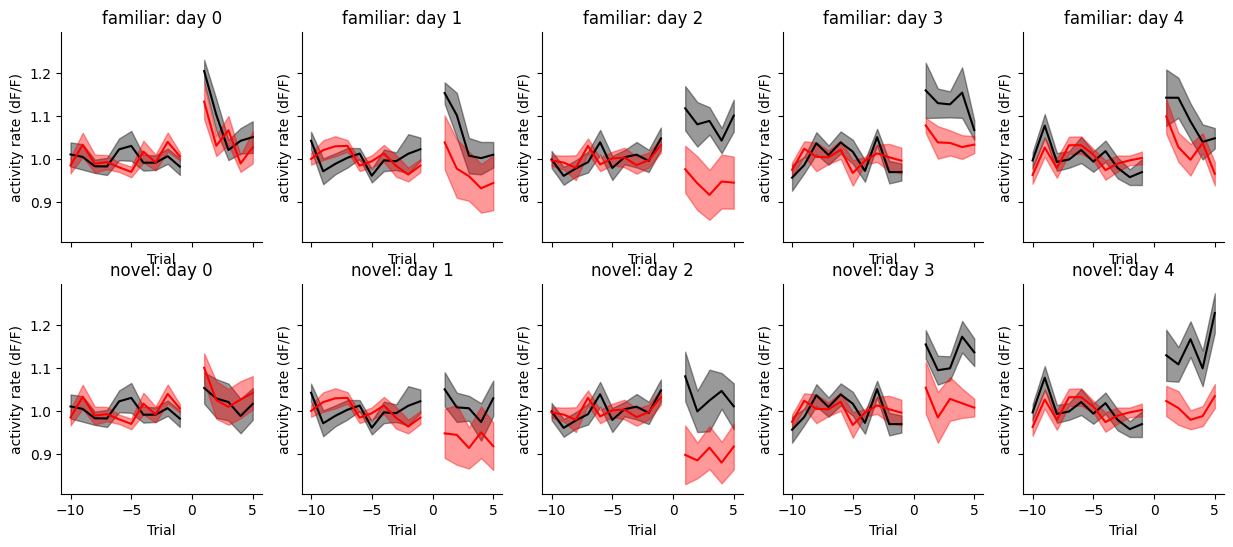

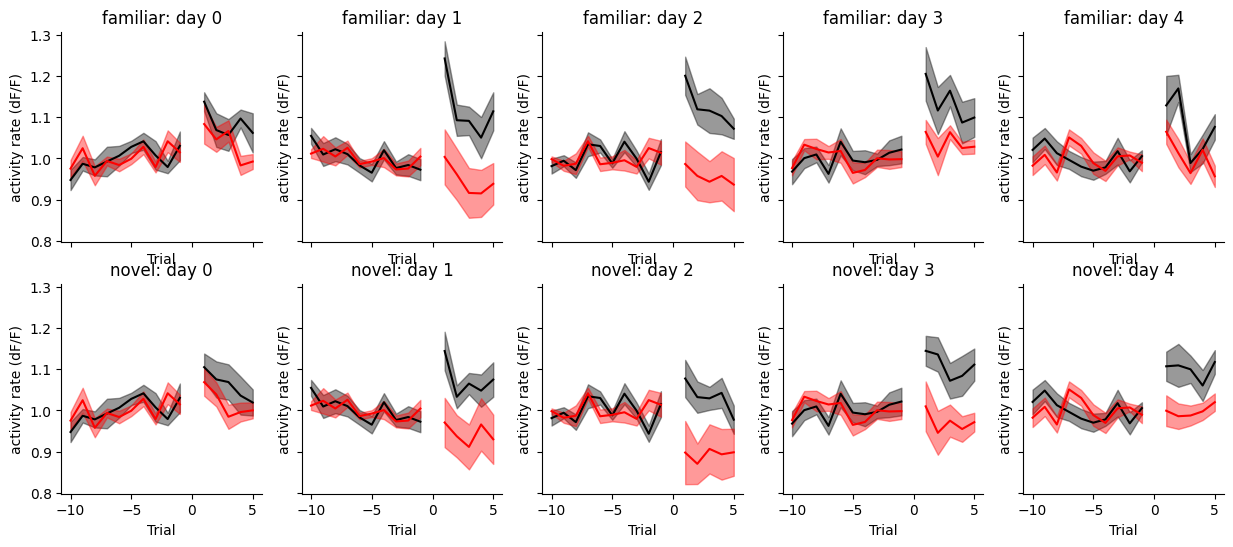

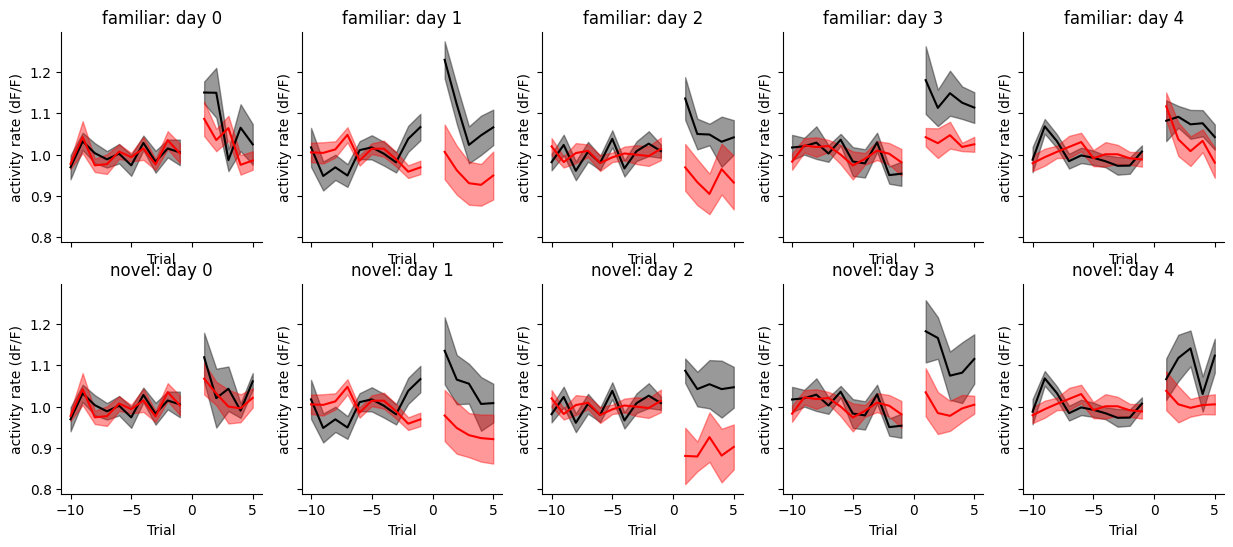

In [13]:
for i in range(10):
    fig, ax = plot_block_avg_downsample(block_rate, norm = None, max_trial=5)
    fig.savefig(figdir / f"block_avg_downsample_perm{i}.pdf")

In [32]:
def build_dataframe(block_rate,  max_trial = 5):
    rng = np.random.default_rng()
    rows = []
    for cond, mice, in block_rate.mouse_dict.items():
        if cond == 'ko':
            n_cells = 270
        else:
            n_cells = 105

        for mouse in mice:
            for day in block_rate.days:
                data = block_rate.activity_rates[cond][mouse][day]

                n_cells = np.minimum(n_cells, data['baseline_act'].shape[-1])
                cells = rng.permutation(data['baseline_act'].shape[-1])[:n_cells]
                
                base = np.nanmean(np.nanmean(data['baseline_act'][:,:,cells],axis=1),axis=-1)
                fam = np.nanmean(np.nanmean(data['block_fam_act'][:,:,cells],axis=1),axis=-1)[:max_trial]/base.mean()
                nov = np.nanmean(np.nanmean(data['block_nov_act'][:,:,cells],axis=1), axis=-1)[:max_trial]/base.mean()
                
                act = {'baseline': base.mean(),
                        'familiar': fam.mean(),
                        'novel': nov.mean()}
                
                for ttype in ('baseline', 'familiar', 'novel'):
                    
                    rows.append({'condition': cond,
                            'mouse': mouse,
                            'day': day,
                            'ttype': ttype,
                            'rate': act[ttype]
                            })


                

    return pd.DataFrame(rows)

In [33]:
df = build_dataframe(block_rate)

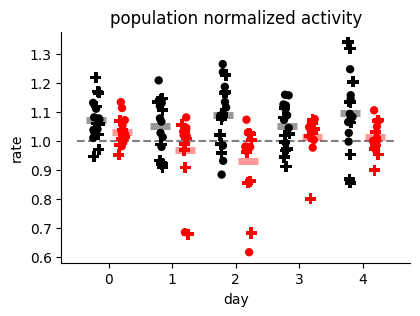

In [48]:
# df = build_dataframe(block_rate)

fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
tmp_df = df.loc[df['day']<5]
sns.stripplot(data=tmp_df.loc[tmp_df['ttype']=='familiar',:],
            x='day',
            y='rate',
            hue='condition', 
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            dodge=True,
            alpha=1.,s=6,
            ax=ax,
            legend=False)

sns.stripplot(data=tmp_df.loc[tmp_df['ttype']=='novel',:],
            x='day',
            y='rate',
            hue='condition', 
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            marker='P', 
            dodge=True,
            alpha= 1., s=8, linewidth=0,
            ax=ax,
            legend=False)

sns.pointplot(data=tmp_df.loc[tmp_df['ttype'].isin(('familiar','novel')),:],
            x='day',
            y='rate',
            errorbar=None,
            estimator=np.mean,
            hue='condition',
            dodge = .4,
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,zorder=10,
            )


#
ax.set_title('population normalized activity')
ax.hlines(1,-.5,4.5, color='gray', linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.savefig(figdir / 'downsample_novel_activity_rate_by_day.pdf', bbox_inches='tight')

In [46]:

import statsmodels.formula.api as smf

df['rank_rate'] = df['rate'].rank()
model = smf.mixedlm(f"rank_rate ~ C(ttype) + C(condition) * C(day) ", df, groups=df['mouse'])
model_result = model.fit()
model_result.summary()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                   Mixed Linear Model Regression Results
============================================================================
Model:                    MixedLM       Dependent Variable:       rank_rate 
No. Observations:         288           Method:                   REML      
No. Groups:               16            Scale:                    2222.5415 
Min. group size:          18            Log-Likelihood:           -1467.6030
Max. group size:          18            Converged:                Yes       
Mean group size:          18.0                                              
----------------------------------------------------------------------------
                                Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
----------------------------------------------------------------------------
Intercept                       56.333    9.887  5.698 0.000  36.955  75.711
C(ttype)[T.familiar]           152.302    6.805 22.382 0.000 138.965 165.639
C(ttype)[T.novel]              135.698    6.805 19.942 0.000 122.361 149.035
C(condition)[T.ko]             -11.810   13.717 -0.861 0.389 -38.694  15.075
C(day)[T.1]                     -6.037   12.831 -0.471 0.638 -31.185  19.111
C(day)[T.2]                      6.556   12.831  0.511 0.609 -18.593  31.704
C(day)[T.3]                     -1.667   12.831 -0.130 0.897 -26.815  23.481
C(day)[T.4]                     11.185   12.831  0.872 0.383 -13.963  36.333
C(day)[T.5]                     -9.296   12.831 -0.725 0.469 -34.444  15.852
C(condition)[T.ko]:C(day)[T.1]  -0.106   19.399 -0.005 0.996 -38.126  37.915
C(condition)[T.ko]:C(day)[T.2] -25.317   19.399 -1.305 0.192 -63.338  12.703
C(condition)[T.ko]:C(day)[T.3]   6.762   19.399  0.349 0.727 -31.259  44.782
C(condition)[T.ko]:C(day)[T.4] -11.804   19.399 -0.609 0.543 -49.825  26.216
C(condition)[T.ko]:C(day)[T.5]  -7.799   19.399 -0.402 0.688 -45.819  30.221
Group Var                        0.000    1.394                             
============================================================================

"""

In [47]:
df['rank_rate'] = df['rate'].rank()
model = smf.mixedlm(f"rank_rate ~ C(ttype) + C(condition) + C(day) ", df, groups=df['mouse'])
model_result = model.fit()
model_result.summary()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
              Mixed Linear Model Regression Results
==================================================================
Model:                MixedLM    Dependent Variable:    rank_rate 
No. Observations:     288        Method:                REML      
No. Groups:           16         Scale:                 2209.9282 
Min. group size:      18         Log-Likelihood:        -1487.8927
Max. group size:      18         Converged:             Yes       
Mean group size:      18.0                                        
------------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept             59.123    8.207  7.204 0.000  43.038  75.209
C(ttype)[T.familiar] 152.302    6.785 22.446 0.000 139.003 165.601
C(ttype)[T.novel]    135.698    6.785 19.999 0.000 122.399 148.997
C(condition)[T.ko]   -18.187    5.584 -3.257 0.001 -29.131  -7.243
C(day)[T.1]           -6.083    9.596 -0.634 0.526 -24.891  12.724
C(day)[T.2]           -4.521    9.596 -0.471 0.638 -23.328  14.287
C(day)[T.3]            1.292    9.596  0.135 0.893 -17.516  20.099
C(day)[T.4]            6.021    9.596  0.627 0.530 -12.787  24.828
C(day)[T.5]          -12.708    9.596 -1.324 0.185 -31.516   6.099
Group Var              0.000    1.378                             
==================================================================

"""